# Introduction

Contexte et objectif : ce notebook réalise une Analyse Exploratoire des Données (EDA) du jeu de données 'Student Performance Factors' afin d'identifier les déterminants statistiques de la réussite scolaire et de formuler des hypothèses exploitables pour la modélisation prédictive.

Méthodologie : nettoyage initial, analyse univariée et bivariée, encodage raisonné des variables catégorielles, évaluation de relations linéaires et non linéaires, puis préparation d'un protocole d'entraînement pour des modèles supervisés.

Livrables : visualisations descriptives, matrice de corrélation commentée, pipelines de prétraitement et résultats d'évaluation de modèles de référence (linéaire et arbres de décision).

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("../Data/Dataset_Student_performance.csv")

# Analyse exploratoire des données (EDA) - objectifs et protocole

In [4]:
df.head(10)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
5,19,88,Medium,Medium,Yes,8,89,Medium,Yes,3,Medium,Medium,Public,Positive,3,No,Postgraduate,Near,Male,71
6,29,84,Medium,Low,Yes,7,68,Low,Yes,1,Low,Medium,Private,Neutral,2,No,High School,Moderate,Male,67
7,25,78,Low,High,Yes,6,50,Medium,Yes,1,High,High,Public,Negative,2,No,High School,Far,Male,66
8,17,94,Medium,High,No,6,80,High,Yes,0,Medium,Low,Private,Neutral,1,No,College,Near,Male,69
9,23,98,Medium,Medium,Yes,8,71,Medium,Yes,0,High,High,Public,Positive,5,No,High School,Moderate,Male,72


In [5]:
df.describe(include='all')

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
count,6607.000000,6607.000000,6607,6607,6607,6607.00000,6607.000000,6607,6607,6607.000000,6607,6529,6607,6607,6607.000000,6607,6517,6540,6607,6607.000000
unique,NaN,NaN,3,3,2,NaN,NaN,3,2,NaN,3,3,2,3,NaN,2,3,3,2,NaN
top,NaN,NaN,Medium,Medium,Yes,NaN,NaN,Medium,Yes,NaN,Low,Medium,Public,Positive,NaN,No,High School,Near,Male,NaN
freq,NaN,NaN,3362,3319,3938,NaN,NaN,3351,6108,NaN,2672,3925,4598,2638,NaN,5912,3223,3884,3814,NaN
mean,19.975329,79.977448,NaN,NaN,NaN,7.02906,75.070531,NaN,NaN,1.493719,NaN,NaN,NaN,NaN,2.967610,NaN,NaN,NaN,NaN,67.235659
std,5.990594,11.547475,NaN,NaN,NaN,1.46812,14.399784,NaN,NaN,1.230570,NaN,NaN,NaN,NaN,1.031231,NaN,NaN,NaN,NaN,3.890456
min,1.000000,60.000000,NaN,NaN,NaN,4.00000,50.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,55.000000
25%,16.000000,70.000000,NaN,NaN,NaN,6.00000,63.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,65.000000
50%,20.000000,80.000000,NaN,NaN,NaN,7.00000,75.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,NaN,67.000000
75%,24.000000,90.000000,NaN,NaN,NaN,8.00000,88.000000,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,69.000000


- **Hours_Studied** : nombre d'heures étudiées par semaine (entier compris entre 1h et 44h).
- **Attendance** : taux de présence en cours (pourcentage compris entre 60 et 100).
- **Parental_Involvement** : niveau d’implication des parents (catégorie : Low / Medium / High).
- **Access_to_Resources** : accès aux ressources éducatives (catégorie : Low / Medium / High).
- **Extracurricular_Activities** : participation à des activités extrascolaires (catégorie : Yes / No).
- **Sleep_Hours** : nombre d’heures de sommeil par nuit (entier compris entre 4 et 10).
- **Previous_Scores** : scores aux évaluations précédentes (entier compris entre 50 et 100).
- **Motivation_Level** : niveau de motivation de l’étudiant (catégorie : Low / Medium / High).
- **Internet_Access** : accès à Internet à domicile (catégorie : Yes / No).
- **Tutoring_Sessions** : nombre de séances de tutorat suivies (entier compris entre 0 et 8).
- **Family_Income** : niveau de revenu familial (catégorie : Low / Medium / High).
- **Teacher_Quality** : qualité perçue de l’enseignant (catégorie : Low / Medium / High).
- **School_Type** : type d’établissement fréquenté (catégorie : Public / Private).
- **Peer_Influence** : influence des pairs (catégorie : Negative / Neutral / Positive).
- **Physical_Activity** : nombre d’heures d’activité physique par semaine (entier compris entre 0 et 6).
- **Learning_Disabilities** : présence d’un trouble de l’apprentissage (catégorie : Yes / No).
- **Parental_Education_Level** : niveau d’éducation des parents (catégorie : High School / College / Postgraduate).
- **Distance_from_Home** : distance entre la maison et l'école (catégorie : Near / Moderate / Far).
- **Gender** : genre de l’étudiant (catégorie : Male / Female).
- **Exam_Score** : score obtenu à l’examen final (entier compris entre 50 et 100).

In [6]:
# Affichage du jeu de données pour inspection initiale (vérification de la lecture CSV)
df

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68


In [7]:
# Vérification des noms de colonnes (structure et ordre)
pd.DataFrame(df.columns,columns=['Column Name'])

,Column Name
0,Hours_Studied
1,Attendance
2,Parental_Involvement
3,Access_to_Resources
4,Extracurricular_Activities
5,Sleep_Hours
6,Previous_Scores
7,Motivation_Level
8,Internet_Access
9,Tutoring_Sessions


In [8]:
# Inspection des types de données par colonne - cohérence et besoins de conversion
pd.DataFrame(df.dtypes,columns=['Data Types'])

,Data Types
Hours_Studied,int64
Attendance,int64
Parental_Involvement,object
Access_to_Resources,object
Extracurricular_Activities,object
Sleep_Hours,int64
Previous_Scores,int64
Motivation_Level,object
Internet_Access,object
Tutoring_Sessions,int64


In [9]:
print("la taille du  Dataset est {} lignes et {} Colonnes". format(len(df), len(df.columns)))

la taille du  Dataset est 6607 lignes et 20 Colonnes


In [10]:
print("Les doublons dans le dataset sont:", df.duplicated().sum())

Les doublons dans le dataset sont: 0


# Analyse - Histogramme des scores finaux (distribution et densité)

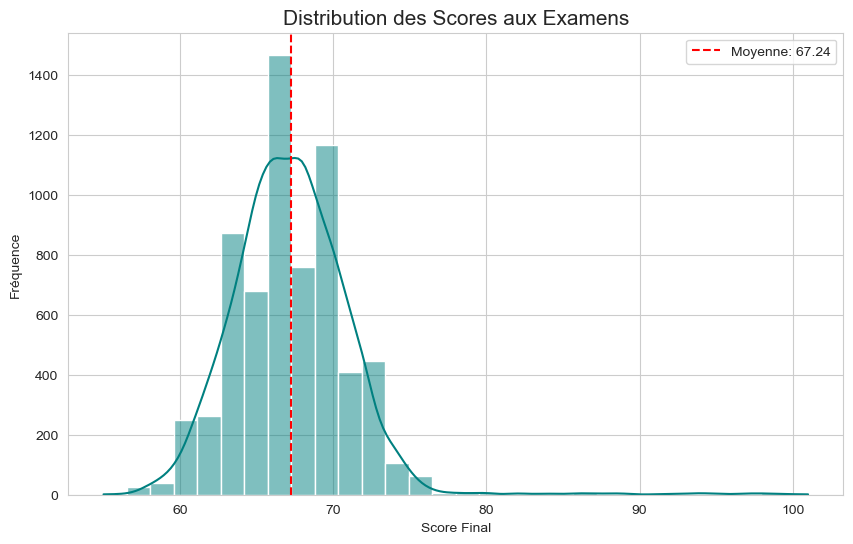

In [11]:
# Configuration esthétique pour des graphiques de qualité publication
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

plt.figure(figsize=(10, 6))
sns.histplot(df['Exam_Score'], kde=True, bins=30, color='teal')
plt.title('Distribution des Scores aux Examens', fontsize=15)
plt.xlabel('Score Final')
plt.ylabel('Fréquence')
plt.axvline(df['Exam_Score'].mean(), color='red', linestyle='--', label=f"Moyenne: {df['Exam_Score'].mean():.2f}")
plt.legend()
plt.show()


La distribution des scores est globalement centrée autour de 67 (moyenne ≈ 67.24).
La forme est relativement symétrique et proche d’une distribution normale, avec une concentration importante entre 62 et 72.

On observe cependant quelques valeurs extrêmes élevées (90–100), qui créent une légère asymétrie à droite.
Globalement, la majorité des étudiants obtiennent des résultats moyens à corrects, avec peu d’échecs sévères.

# Analyse - Nuage de points : relation entre heures d'étude/assiduité et score final

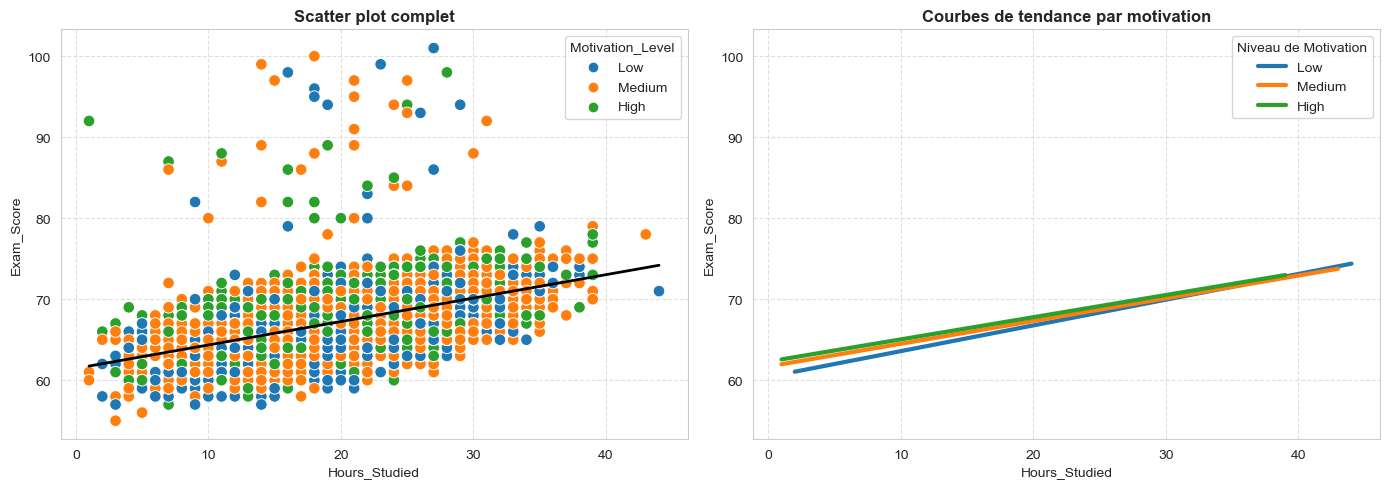

In [12]:
custom_palette = {
    "Low": "#1f77b4",
    "Medium": "#ff7f0e",
    "High": "#2ca02c"
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot original
sns.scatterplot(
    data=df,
    x="Hours_Studied",
    y="Exam_Score",
    hue="Motivation_Level",
    palette=custom_palette,
    s=70,
    ax=axes[0]
)

# Courbe de tendance globale
sns.regplot(
    data=df,
    x="Hours_Studied",
    y="Exam_Score",
    scatter=False,
    ci=None,
    line_kws={"linewidth": 2, "color": "black", "linestyle": "-"},
    ax=axes[0]
)

axes[0].set_title("Scatter plot complet", fontweight="bold")
axes[0].grid(True, linestyle="--", alpha=0.6)

# Sauvegarde des limites pour les réutiliser
x_limits = axes[0].get_xlim()
y_limits = axes[0].get_ylim()

# Courbes de tendance uniquement par motivation
for level, color in custom_palette.items():
    subset = df[df["Motivation_Level"] == level]
    
    sns.regplot(
        data=subset,
        x="Hours_Studied",
        y="Exam_Score",
        scatter=False,
        ci=None,
        line_kws={"linewidth": 3, "color": color},
        ax=axes[1]
    )

axes[1].set_title("Courbes de tendance par motivation", fontweight="bold")
axes[1].set_xlim(x_limits)
axes[1].set_ylim(y_limits)
axes[1].grid(True, linestyle="--", alpha=0.6)

axes[1].legend(custom_palette.keys(), title="Niveau de Motivation")

plt.tight_layout()
plt.show()

Le premier graphique (scatter plot) met en évidence une relation positive nette entre le nombre d’heures étudiées et le score à l’examen : plus le temps d’étude augmente, plus les scores tendent à progresser. La majorité des observations se concentrent entre 5 et 35 heures, avec des scores principalement compris entre 60 et 75. 

On observe cependant une dispersion des données pour un même volume d’heures, ce qui indique que le temps d’étude n’est pas le seul facteur explicatif de la performance.

Le second graphique,  présente uniquement les courbes de tendance par niveau de motivation. Les trois droites sont globalement parallèles, ce qui suggère que l’effet marginal d’une heure supplémentaire d’étude est similaire quel que soit le niveau de motivation. En revanche, les courbes « Medium » et « High » se situent légèrement au-dessus de la courbe « Low », indiquant qu’à nombre d’heures équivalent, un niveau de motivation plus élevé est associé à un score légèrement supérieur.

Ainsi, le temps d’étude apparaît comme un des facteurs principaux influençant la performance, tandis que la motivation joue un rôle complémentaire en décalant légèrement le niveau global des résultats, sans modifier fortement la dynamique de progression.


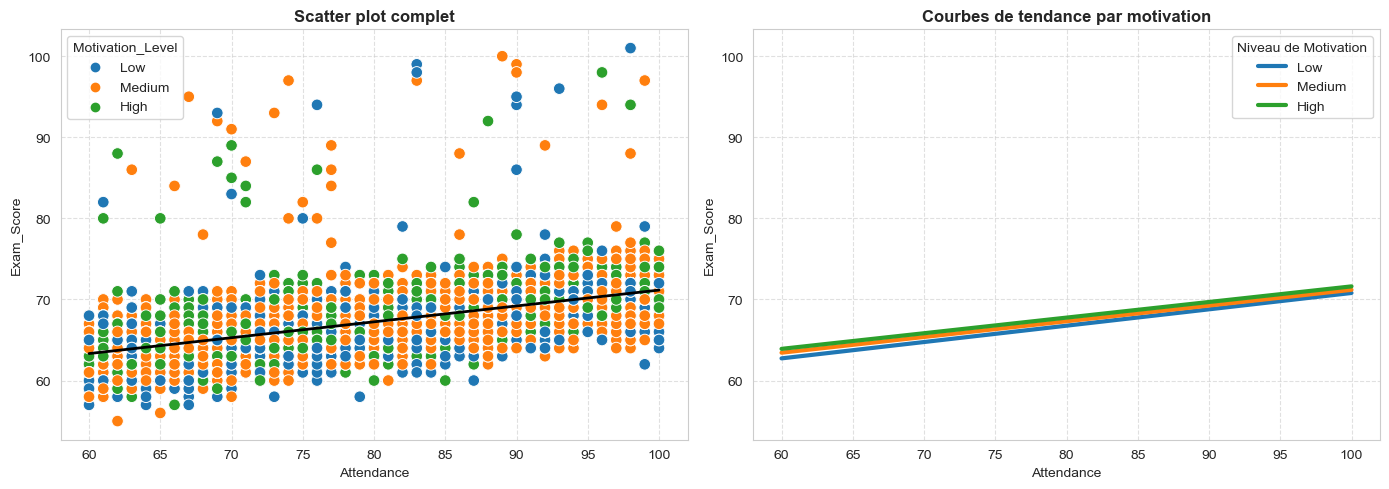

In [13]:
custom_palette = {
    "Low": "#1f77b4",
    "Medium": "#ff7f0e",
    "High": "#2ca02c"
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot original
sns.scatterplot(
    data=df,
    x="Attendance",
    y="Exam_Score",
    hue="Motivation_Level",
    palette=custom_palette,
    s=70,
    ax=axes[0]
)

# Courbe de tendance globale
sns.regplot(
    data=df,
    x="Attendance",
    y="Exam_Score",
    scatter=False,
    ci=None,
    line_kws={"linewidth": 2, "color": "black", "linestyle": "-"},
    ax=axes[0]
)

axes[0].set_title("Scatter plot complet", fontweight="bold")
axes[0].grid(True, linestyle="--", alpha=0.6)

# Sauvegarde des limites pour les réutiliser
x_limits = axes[0].get_xlim()
y_limits = axes[0].get_ylim()

# Courbes de tendance uniquement par motivation
for level, color in custom_palette.items():
    subset = df[df["Motivation_Level"] == level]
    
    sns.regplot(
        data=subset,
        x="Attendance",
        y="Exam_Score",
        scatter=False,
        ci=None,
        line_kws={"linewidth": 3, "color": color},
        ax=axes[1]
    )

axes[1].set_title("Courbes de tendance par motivation", fontweight="bold")
axes[1].set_xlim(x_limits)
axes[1].set_ylim(y_limits)
axes[1].grid(True, linestyle="--", alpha=0.6)

axes[1].legend(custom_palette.keys(), title="Niveau de Motivation")

plt.tight_layout()
plt.show()

Le premier graphique (scatter plot) met en évidence une relation positive entre le taux de présence (Attendance) et le score à l’examen : plus la présence en cours augmente, plus les scores tendent à être élevés. La majorité des observations se situent entre 60 % et 100 % de présence, avec des scores principalement compris entre 60 et 75.

On observe toutefois une dispersion importante des points pour un même niveau de présence, ce qui suggère que l’assiduité n’est pas le seul facteur expliquant la performance académique. Certains étudiants avec une présence relativement élevée obtiennent des scores moyens, tandis que d’autres atteignent des scores élevés, indiquant l’influence probable d’autres variables (temps d’étude, motivation, etc.).

Le second graphique présente uniquement les courbes de tendance par niveau de motivation. Les trois droites sont très proches et presque parallèles, ce qui indique que l’effet marginal d’une augmentation de la présence sur le score est similaire quel que soit le niveau de motivation.

On observe néanmoins que la courbe correspondant au niveau de motivation High se situe légèrement au-dessus des autres, suivie de Medium, puis Low. Cela suggère qu’à niveau de présence équivalent, les étudiants les plus motivés obtiennent en moyenne des scores légèrement plus élevés.

Ainsi, la présence en cours apparaît comme un facteur positif associé à la performance, tandis que la motivation agit comme un facteur complémentaire, influençant le niveau moyen des résultats sans modifier significativement la relation entre présence et score.


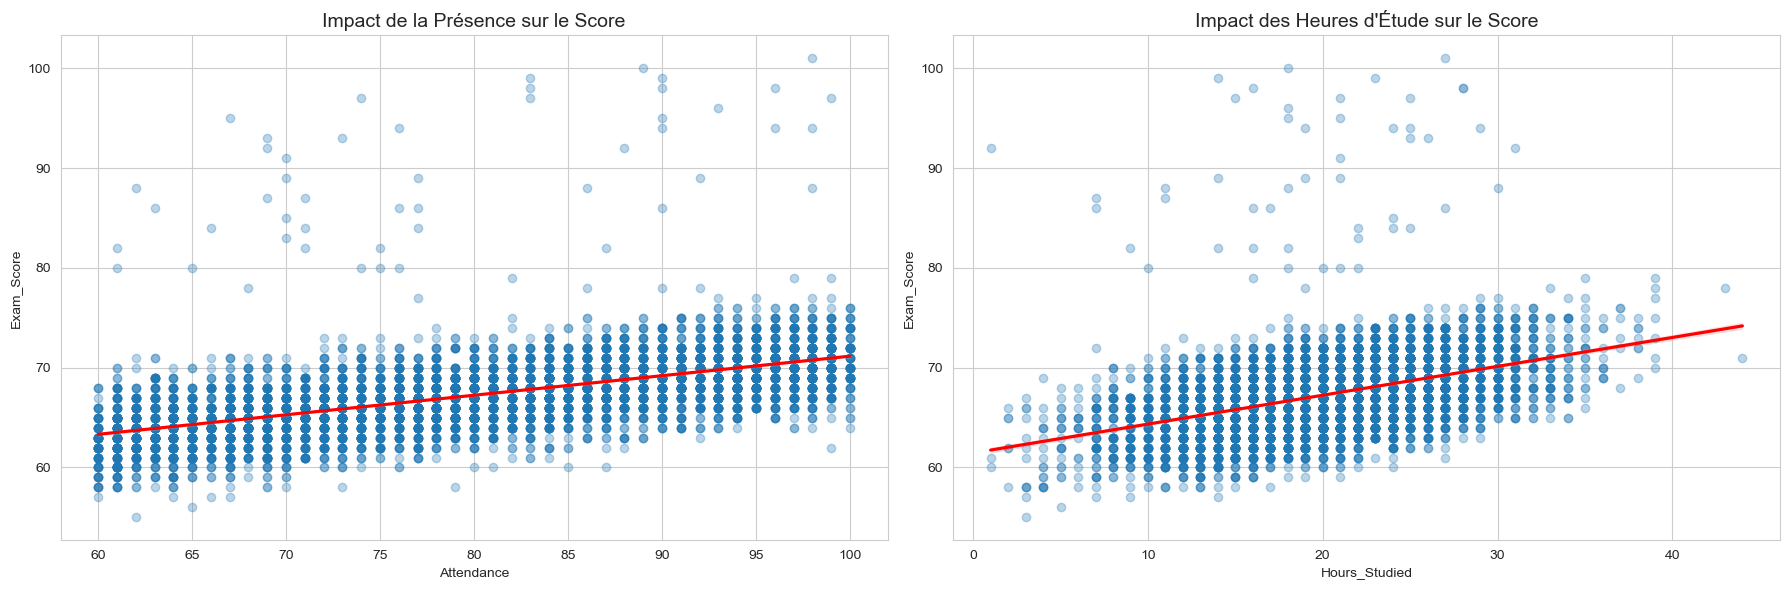

In [14]:
# Focus sur les relations clés
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Relation Attendance vs Score
sns.regplot(x='Attendance', y='Exam_Score', data=df, ax=axes[0], scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
axes[0].set_title('Impact de la Présence sur le Score', fontsize=14)

# Relation Hours_Studied vs Score
sns.regplot(x='Hours_Studied', y='Exam_Score', data=df, ax=axes[1], scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
axes[1].set_title('Impact des Heures d\'Étude sur le Score', fontsize=14)

plt.tight_layout()
plt.show()

Le graphique montre une relation positive claire entre la présence (attendance) et le score.
- Plus le taux de présence augmente, plus le score tend à progresser.
- La pente reste modérée mais constante.
- La dispersion indique que la présence n’explique pas entièrement la performance.

On observe une relation positive plus marquée pour les heures étudiées (Hours_Sstudied) que pour la présence.
- L’augmentation des heures d’étude est associée à une hausse plus visible du score.
- La pente est plus forte que celle observée pour la présence.
- Malgré cela, une variabilité persiste.

# Analyse - Distribution des scores par type d'établissement (violin plot)

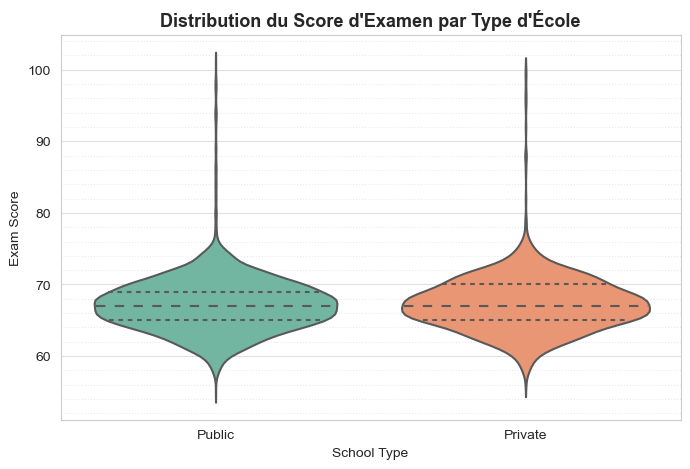

In [15]:
from matplotlib.ticker import MultipleLocator

# Exam Score distribution by School Type
plt.figure(figsize=(8,5))
sns.violinplot(data=df, x="School_Type", y="Exam_Score", palette="Set2", inner="quartile")
plt.title("Distribution du Score d'Examen par Type d'École", fontsize=13, fontweight="bold")
plt.xlabel("School Type")
plt.ylabel("Exam Score")

# Grille principale et sous-grille
ax = plt.gca()
ax.yaxis.set_minor_locator(MultipleLocator(2))
plt.grid(axis="y", linestyle="-", alpha=0.6, which="major")
plt.grid(axis="y", linestyle=":", alpha=0.4, which="minor")

plt.show()

Ce diagramme en violon représente la distribution des scores d’examen selon le type d’école (public ou privé). Les deux distributions présentent une forme très similaire, avec une concentration principale des scores autour de 65–70.

La dispersion des scores est comparable entre les deux groupes : l’étendue et la densité centrale sont proches, ce qui suggère une variabilité similaire des performances. On observe également des valeurs élevées dans les deux types d’écoles, indiquant que des scores très importants ne sont pas spécifiques à un seul groupe.

Globalement, le type d’école ne semble pas générer de différence marquée dans la performance moyenne. L’effet, s’il existe, apparaît modéré comparé à d’autres variables potentielles (comme les heures d’étude ou la motivation).

# Analyse - Boxplot : distribution des scores selon le niveau d'éducation des parents et l'accès aux ressources

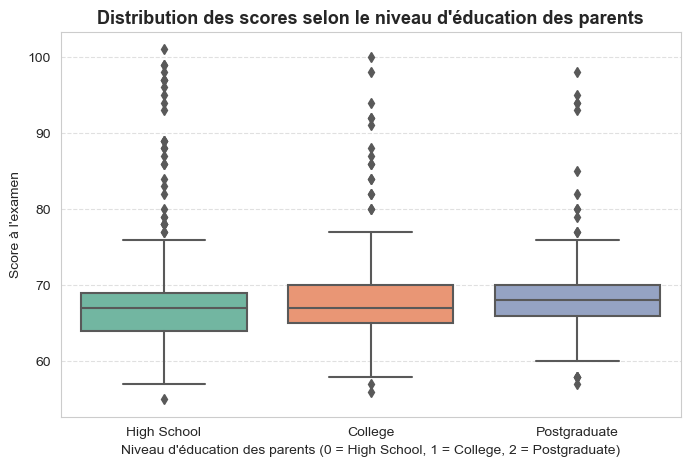

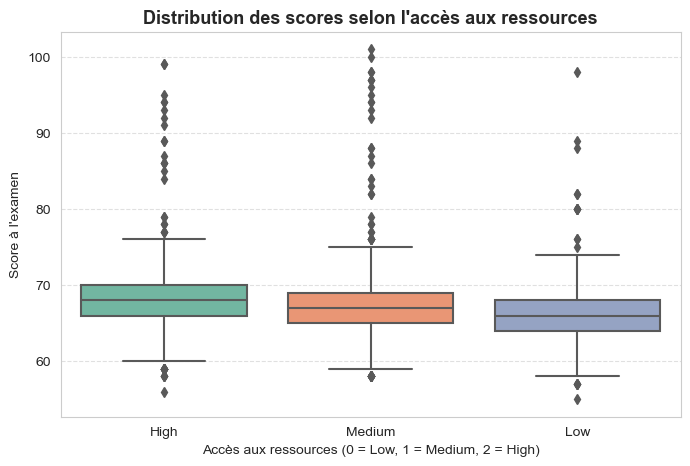

In [16]:
# Parental Education Level
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Parental_Education_Level",
    y="Exam_Score",
    palette="Set2"
)

plt.title("Distribution des scores selon le niveau d'éducation des parents",
          fontsize=13, fontweight="bold")
plt.xlabel("Niveau d'éducation des parents (0 = High School, 1 = College, 2 = Postgraduate)")
plt.ylabel("Score à l'examen")

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()


# Access to Resources
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Access_to_Resources",
    y="Exam_Score",
    palette="Set2"
)

plt.title("Distribution des scores selon l'accès aux ressources",
          fontsize=13, fontweight="bold")
plt.xlabel("Accès aux ressources (0 = Low, 1 = Medium, 2 = High)")
plt.ylabel("Score à l'examen")

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

Les boxplots montrent des différences faibles mais progressives :
- Les étudiants dont les parents ont un niveau Postgraduate semblent avoir une médiane légèrement plus élevée.
- Les niveaux High School et College sont proches.
- L’écart reste modéré.

**Le niveau d’éducation parental influence légèrement la performance, mais l’effet est limité.**

Les différences sont plus visibles ici :
- Accès High → médiane légèrement plus élevée.
- Accès Low → médiane plus basse.
- L’écart reste cependant modéré.

**L’accès aux ressources semble avoir un impact plus marqué que le niveau d’éducation des parents.**

# Analyse - Barplot : score moyen par niveau d'implication parentale

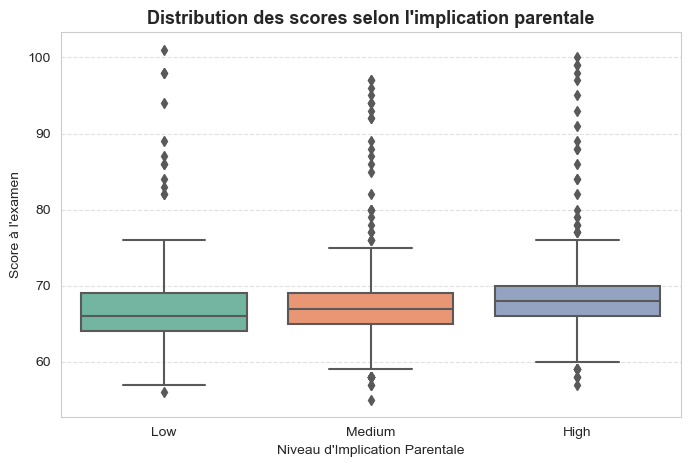

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Parental_Involvement",
    y="Exam_Score",
    palette="Set2"
)

plt.title("Distribution des scores selon l'implication parentale",
          fontsize=13, fontweight="bold")
plt.xlabel("Niveau d'Implication Parentale")
plt.ylabel("Score à l'examen")

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

# Analyse - Boxplot : distribution des scores par genre

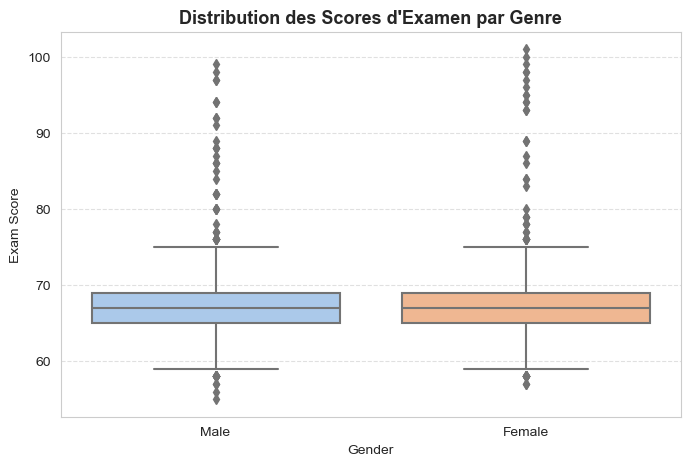

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Gender", y="Exam_Score", palette="pastel")
plt.title("Distribution des Scores d'Examen par Genre", fontsize=13, fontweight="bold")
plt.xlabel("Gender")
plt.ylabel("Exam Score")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

Ce graphique présente le score moyen à l’examen selon le niveau d’implication parentale (Low, Medium, High). On observe une progression légère mais régulière : le score moyen augmente à mesure que l’implication parentale s’élève.

Les élèves ayant une implication parentale faible ont le score moyen le plus bas, ceux avec une implication moyenne obtiennent un score légèrement supérieur, et ceux bénéficiant d’une implication élevée affichent la moyenne la plus haute.

Cependant, l’écart entre les groupes reste relativement modéré (quelques points seulement). Cela suggère que l’implication parentale a un effet positif sur la performance, mais que son impact n’est pas massif comparé à des facteurs plus directement liés au comportement de l’élève (comme les heures d’étude).

**Nous ne remarquons aucune différence entre les scores obtenus selon le genre.**

# Analyse - Répartition proportionnelle par type d'établissement (diagramme circulaire)

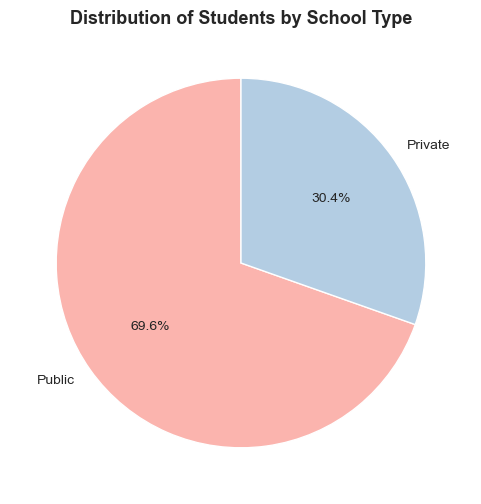

In [19]:
# Pie chart: Distribution of School Type
school_counts = df["School_Type"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    school_counts,
    labels=school_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.Pastel1.colors,
    textprops={'fontsize': 10}
)
plt.title("Distribution of Students by School Type", fontsize=13, fontweight="bold")
plt.show()

# Encodage des données

In [20]:
# Sélectionne les colonnes de type 'object' (chaînes de caractères)
categorical_cols = df.select_dtypes(include=['object']).columns

# Affiche les valeurs uniques pour chacune de ces colonnes
for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")

Parental_Involvement: ['Low' 'Medium' 'High']
Access_to_Resources: ['High' 'Medium' 'Low']
Extracurricular_Activities: ['No' 'Yes']
Motivation_Level: ['Low' 'Medium' 'High']
Internet_Access: ['Yes' 'No']
Family_Income: ['Low' 'Medium' 'High']
Teacher_Quality: ['Medium' 'High' 'Low' nan]
School_Type: ['Public' 'Private']
Peer_Influence: ['Positive' 'Negative' 'Neutral']
Learning_Disabilities: ['No' 'Yes']
Parental_Education_Level: ['High School' 'College' 'Postgraduate' nan]
Distance_from_Home: ['Near' 'Moderate' 'Far' nan]
Gender: ['Male' 'Female']


In [21]:
# 1. Définition des dictionnaires de correspondance
# On respecte l'ordre logique (0 est le plus faible, 2 ou 3 le plus fort)
logic_map = {'Low': 0, 'Medium': 1, 'High': 2}
binary_map = {'No': 0, 'Yes': 1}
edu_map = {'High School': 0, 'College': 1, 'Postgraduate': 2}
dist_map = {'Near': 0, 'Moderate': 1, 'Far': 2}
peer_map = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
school_map = {'Public': 0, 'Private': 1}
gender_map = {'Male': 0, 'Female': 1}

# 2. Application du mapping par groupe de colonnes
# Colonnes à 3 niveaux (Low/Medium/High)
cols_3_levels = ['Parental_Involvement', 'Access_to_Resources', 'Motivation_Level', 'Family_Income', 'Teacher_Quality']
for col in cols_3_levels:
    df[col] = df[col].map(logic_map)

# Colonnes Oui/Non
cols_binary = ['Extracurricular_Activities', 'Internet_Access', 'Learning_Disabilities']
for col in cols_binary:
    df[col] = df[col].map(binary_map)

# Colonnes spécifiques
df['Parental_Education_Level'] = df['Parental_Education_Level'].map(edu_map)
df['Distance_from_Home'] = df['Distance_from_Home'].map(dist_map)
df['Peer_Influence'] = df['Peer_Influence'].map(peer_map)
df['School_Type'] = df['School_Type'].map(school_map)
df['Gender'] = df['Gender'].map(gender_map)

# 3. Vérification : tout doit être numérique maintenant
print(df.dtypes)

Hours_Studied                   int64
Attendance                      int64
Parental_Involvement            int64
Access_to_Resources             int64
Extracurricular_Activities      int64
Sleep_Hours                     int64
Previous_Scores                 int64
Motivation_Level                int64
Internet_Access                 int64
Tutoring_Sessions               int64
Family_Income                   int64
Teacher_Quality               float64
School_Type                     int64
Peer_Influence                  int64
Physical_Activity               int64
Learning_Disabilities           int64
Parental_Education_Level      float64
Distance_from_Home            float64
Gender                          int64
Exam_Score                      int64
dtype: object


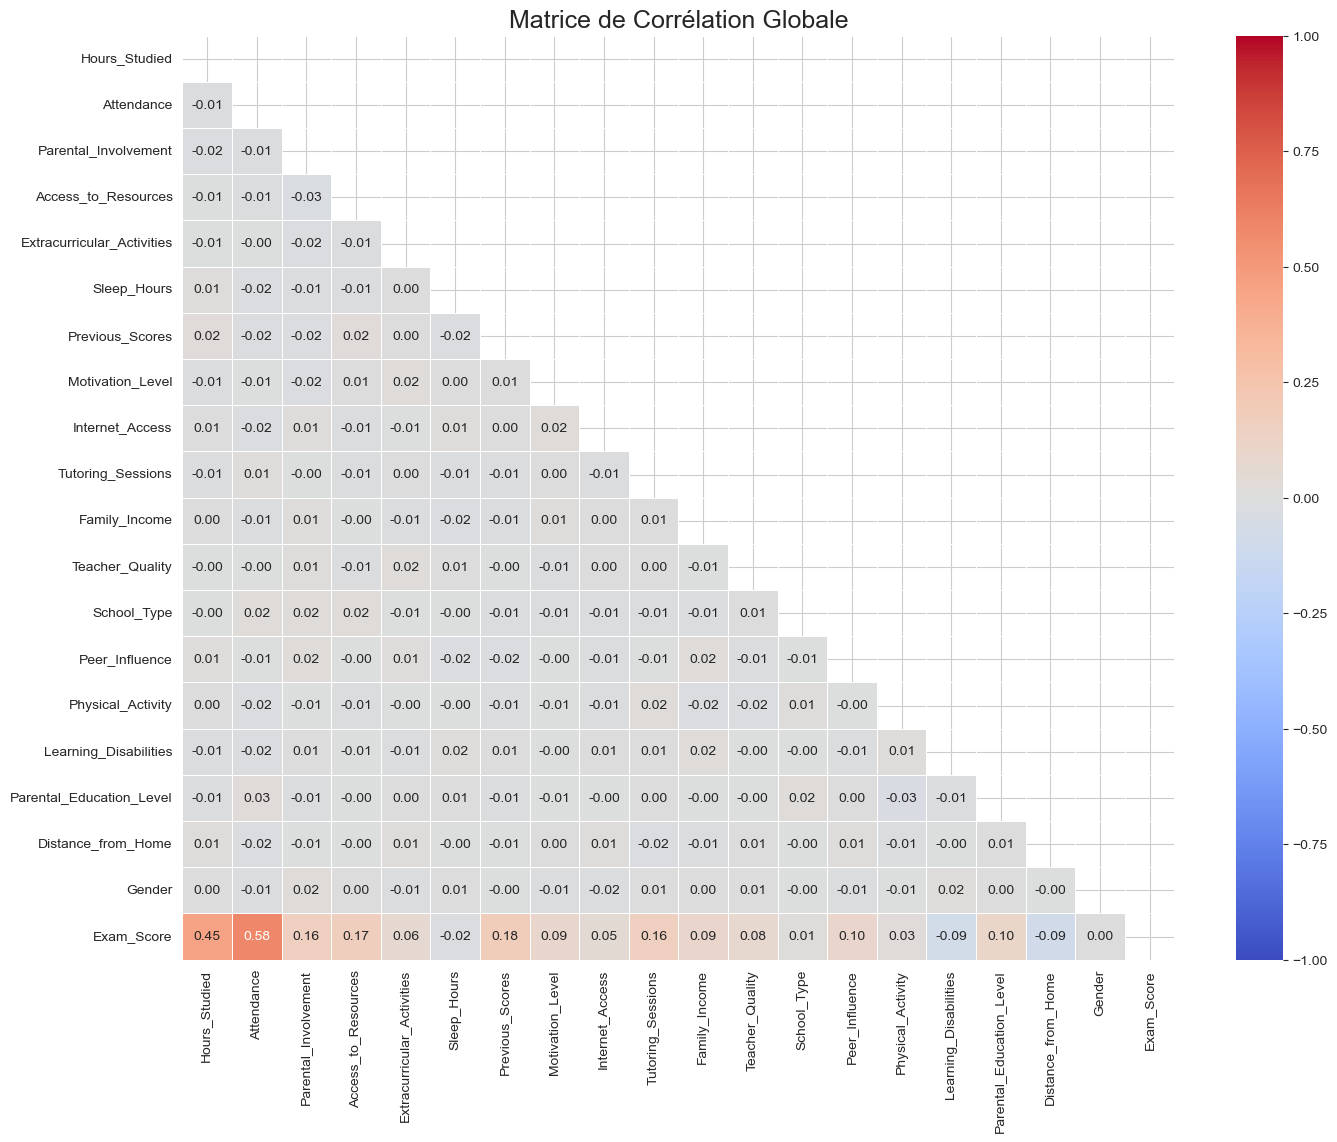

In [22]:
# Matrice de Corrélation
plt.figure(figsize=(16, 12))
correlation_matrix = df.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool)) # Masquer la partie supérieure pour la lisibilité

sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matrice de Corrélation Globale', fontsize=18)
plt.show()

Limites de l'approche : la matrice de corrélation de Pearson est partiellement inadaptée ici car de nombreuses variables sont d'origine catégorielle et ont été encodées en valeurs numériques. Ce type de corrélation linéaire peut sous-estimer ou masquer des relations non linéaires et des effets d'interaction. En pratique, il convient d'associer cette analyse à des visualisations ciblées (boxplots, violins, scatterplots) et à des modèles capables de capturer des dépendances complexes (arbres, méthodes d'ensemble). Les étapes suivantes privilégient donc une approche graphique et des pipelines de prétraitement robustes avant modélisation.

On se concentre surtout sur la ligne Exam_Score.

* **Corrélations les plus fortes**
    - Attendance : 0.58
    - Hours_Studied : 0.45
    Ce sont les deux variables les plus corrélées au score.


* **Interprétation :**
    - Plus la présence est élevée, plus le score augmente.
    - Plus les heures d’étude augmentent, plus le score augmente.
    - La présence semble même légèrement plus corrélée que les heures d’étude.


* **Corrélations modérées**
    - Previous_Scores : 0.18
    - Access_to_Resources : 0.17
    - Parental_Involvement : 0.16
    - Tutoring_Sessions : 0.16
    Effet positif mais plus faible.
    Cela suggère que ces variables influencent la performance, mais moins directement que le comportement académique (étude + présence).


* **Corrélations faibles / quasi nulles**
    - Sleep_Hours : -0.02
    - School_Type : 0.01
    - Gender : 0.00
    - Distance_from_Home : -0.09
    - Learning_Disabilities : -0.09...
    Effet très faible.


* **Important :**
    Une corrélation faible ne signifie pas absence totale d’impact, mais elle indique que la relation linéaire directe est faible.


* **Ce qu’on remarque aussi**
    Entre les variables explicatives elles-mêmes :
    - Les corrélations sont très faibles (proches de 0).
    - Donc pas de multicolinéarité forte.
    C’est très bon pour un modèle linéaire.


* **Conclusion EDA corrélation**
    Les facteurs les plus déterminants semblent être :
    - Attendance
    - Hours_Studied
    - Previous_Scores
    - Les facteurs socio-économiques ont un impact plus modéré.

# ML - Baseline et random forest

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


In [24]:

# 1. Préparation des données
# On sépare la cible (y) des features (X)
X = df.drop('Exam_Score', axis=1)
y = df['Exam_Score']

# Identification automatique des colonnes numériques et catégorielles
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'category']).columns


In [25]:

# 2. Séparation Train / Test - répartition 80/20 (random_state pour la reproductibilité)
# Cette séparation garantit une estimation hors échantillon des performances modèles
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def analyze_split(y, name):
    total = len(y)
    above_80 = np.sum(y > 80)
    above_75 = np.sum(y > 75)
    
    print(f"\n--- {name} ---")
    print(f"Total: {total}")
    print(f">75: {above_75} ({above_75/total*100:.2f}%)")
    print(f">80: {above_80} ({above_80/total*100:.2f}%)")

analyze_split(y, "Dataset complet")
analyze_split(y_train, "Train")
analyze_split(y_test, "Test")



--- Dataset complet ---
Total: 6607
>75: 76 (1.15%)
>80: 43 (0.65%)

--- Train ---
Total: 5285
>75: 67 (1.27%)
>80: 37 (0.70%)

--- Test ---
Total: 1322
>75: 9 (0.68%)
>80: 6 (0.45%)


In [26]:

# 3. Construction du préprocesseur - pipeline de transformation des features
# Stratégie : imputation robuste des numériques (médiane) + normalisation ; imputation nominale + encodage One-Hot pour catégorielles
# Les choix ci‑dessous visent la reproductibilité et la stabilité des modèles linéaires et non linéaires
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])


In [ ]:
# 4. Définition des Modèles

# Modèle A : Baseline (Régression Linéaire)
# Simple, rapide, hautement interprétable. Sert de référence.
model_lr = Pipeline(steps=[('preprocessor', preprocessor),
                           ('regressor', LinearRegression())])

# Modèle B : Random Forest
# Capable de capter des non-linéarités complexes et robuste aux outliers.
model_rf = Pipeline(steps=[('preprocessor', preprocessor),
                           ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))])


In [28]:

# 5. Entraînement et Évaluation
print("Entraînement des modèles en cours...")

results = {}

for name, model in [("Régression Linéaire", model_lr), ("Random Forest", model_rf)]:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {'RMSE': rmse, 'R2': r2}
    print(f"\n--- {name} ---")
    print(f"RMSE (Erreur Moyenne): {rmse:.4f}")
    print(f"R² (Variance Expliquée): {r2:.4f}")


Entraînement des modèles en cours...

--- Régression Linéaire ---
RMSE (Erreur Moyenne): 1.7996
R² (Variance Expliquée): 0.7709

--- Random Forest ---
RMSE (Erreur Moyenne): 2.1627
R² (Variance Expliquée): 0.6691


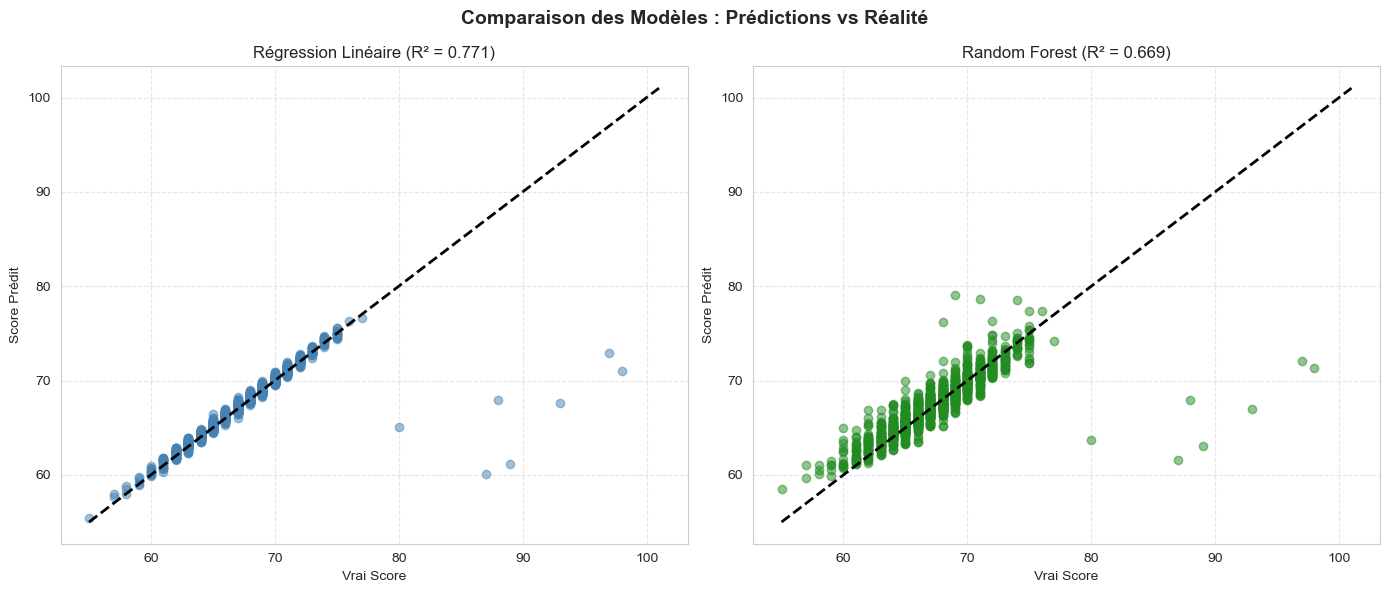

In [29]:
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)

model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

r2_lr = r2_score(y_test, y_pred_lr)
r2_rf = r2_score(y_test, y_pred_rf)

# Création des deux graphiques côte à côte
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Graphique Régression Linéaire ---
axes[0].scatter(y_test, y_pred_lr, alpha=0.5, color='steelblue')
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
axes[0].set_xlabel("Vrai Score")
axes[0].set_ylabel("Score Prédit")
axes[0].set_title(f"Régression Linéaire (R² = {r2_lr:.3f})")
axes[0].grid(True, linestyle="--", alpha=0.5)

# --- Graphique Random Forest ---
axes[1].scatter(y_test, y_pred_rf, alpha=0.5, color='forestgreen')
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
axes[1].set_xlabel("Vrai Score")
axes[1].set_ylabel("Score Prédit")
axes[1].set_title(f"Random Forest (R² = {r2_rf:.3f})")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.suptitle("Comparaison des Modèles : Prédictions vs Réalité", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


Analyse des résultats : Le fait que la Régression Linéaire (0.77) batte le Random Forest (0.67) indique que la structure des données est  linéaire.
Le Random Forest est probablement en train d'overfitter (il apprend le bruit au lieu de la tendance) car il est trop complexe pour ce dataset précis sans réglage fin (tuning).

La stratégie d'amélioration : Puisque le modèle linéaire fonctionne bien, nous n'allons pas changer de famille d'algorithme. Nous allons plutôt enrichir la linéarité en introduisant des Features Polynomiales.

# PARTIE AVANCÉE - Empilement (stacking) et sélection de variables

--- Sélection via LASSO ---
Variables retenues par LASSO: 18
Alpha optimal: 0.0074
--- Entraînement du modèle Stacking ---
RMSE (Stacking): 1.7995
R² (Stacking): 0.7709


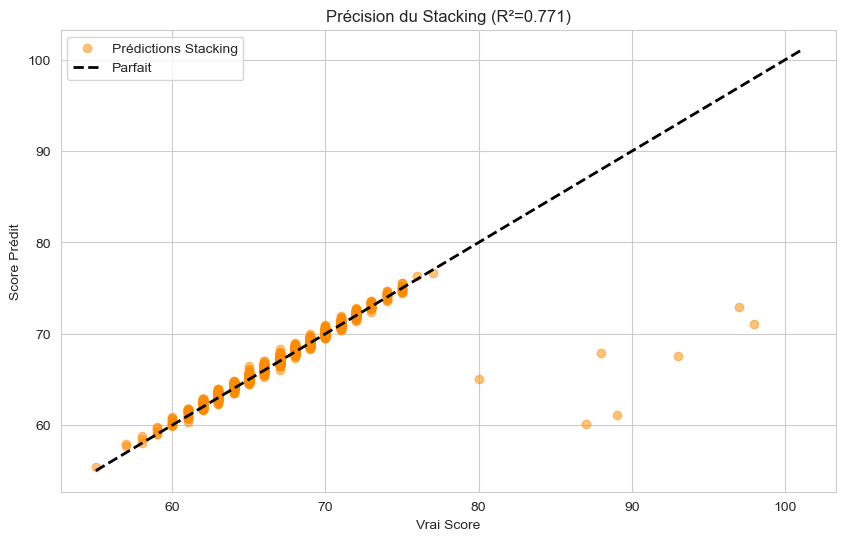

In [30]:
from sklearn.ensemble import StackingRegressor, GradientBoostingRegressor
from sklearn.linear_model import RidgeCV, LassoCV

# 1. Sélection automatique de variables via LASSO (L1)
# Le Lasso est utilisé ici pour sa capacité à contraindre certains coefficients à zéro, facilitant une première sélection de features.
print("--- Sélection via LASSO ---")

# Pipeline dédié associant le préprocesseur et la sélection LASSO (CV intégrée pour alpha)
lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('selector', LassoCV(cv=5, random_state=42))
])

lasso_pipeline.fit(X_train, y_train)

# Extraction des coefficients et comptage des variables conservées
lasso_model = lasso_pipeline.named_steps['selector']
coefs = lasso_model.coef_
kept_features = np.sum(coefs != 0)
print(f"Variables retenues par LASSO: {kept_features}")
print(f"Alpha optimal: {lasso_model.alpha_:.4f}")
print("=" * 30)

# 2. Empilement (Stacking) - combiner experts linéaires et non-linéaires
# Principe : agréger les prédictions de modèles complémentaires via un estimateur final régularisé
estimators = [
    ('ridge', RidgeCV()),
    ('gb', GradientBoostingRegressor(n_estimators=200, random_state=42))
]

stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=RidgeCV()
)

model_stacking = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('stacking', stacking_model)
])

print("--- Entraînement du modèle Stacking ---")
model_stacking.fit(X_train, y_train)

# Évaluation hors-échantillon
y_pred_stack = model_stacking.predict(X_test)
rmse_stack = np.sqrt(mean_squared_error(y_test, y_pred_stack))
r2_stack = r2_score(y_test, y_pred_stack)
print(f"RMSE (Stacking): {rmse_stack:.4f}")
print(f"R² (Stacking): {r2_stack:.4f}")

# Visualisation diagnostic : prédiction vs réalité
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_stack, alpha=0.5, color='darkorange', label='Prédictions Stacking')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2, label='Parfait')
plt.xlabel('Vrai Score')
plt.ylabel('Score Prédit')
plt.title(f'Précision du Stacking (R²={r2_stack:.3f})')
plt.legend()
plt.show()

On observe :
- Une très bonne alignement des points entre 55 et 75.
- Les prédictions suivent bien la diagonale (ligne parfaite).
- R² ≈ 0.77 → le modèle explique 77% de la variance.
Le modèle est globalement performant.

**Mais on remarque quelque chose d’important :**
Pour les scores très élevés (80–100) le modèle sous-estime fortement.

**Exemple :**
- Vrai score ≈ 95
- Score prédit ≈ 70


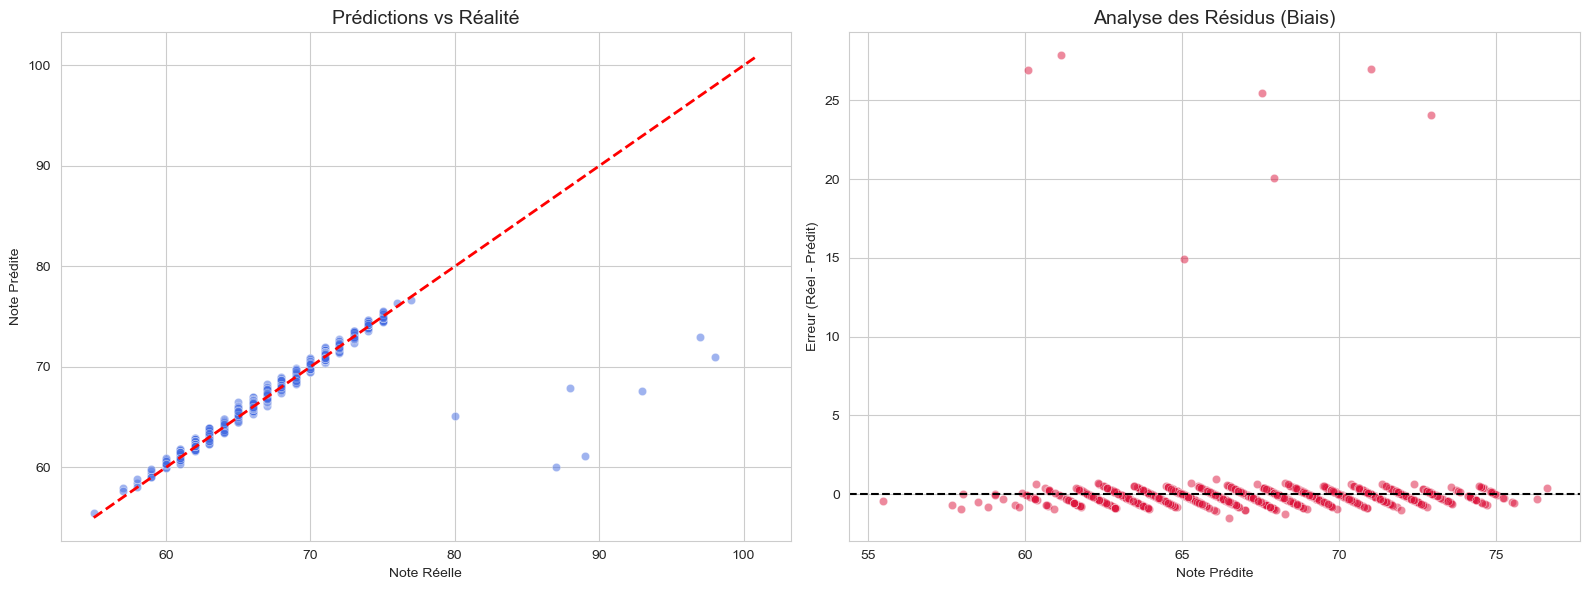

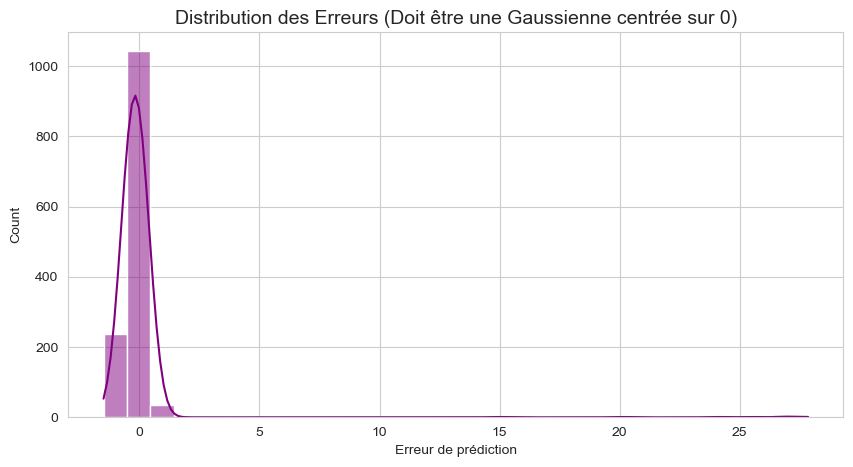


HÉTÉROSCÉDASTICITÉ - Analyse par segment

Variance des erreurs par segment :
  Élèves faibles (≤Q1): σ = 0.360
  Élèves moyens  (Q1-Q3): σ = 0.347
  Très bons      (≥Q3): σ = 3.426
  → Ratio (Forts/Faibles): 9.51x
  ALERTE: Fiabilité inégale


In [31]:
# DIAGNOSTIC DES ERREURS (RESIDUAL ANALYSIS)

# On reprend les prédictions du meilleur modèle (ex: Stacking ou Ridge)
best_pred = y_pred_stack # ou y_pred_poly selon les résultats

residuals = y_test - best_pred

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphique 1 : Prédiction vs Réel
sns.scatterplot(x=y_test, y=best_pred, ax=axes[0], alpha=0.5, color='royalblue')
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[0].set_title('Prédictions vs Réalité', fontsize=14)
axes[0].set_xlabel('Note Réelle')
axes[0].set_ylabel('Note Prédite')

# Graphique 2 : Résidus vs Prédictions (Homoscédasticité)
sns.scatterplot(x=best_pred, y=residuals, ax=axes[1], alpha=0.5, color='crimson')
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_title('Analyse des Résidus (Biais)', fontsize=14)
axes[1].set_xlabel('Note Prédite')
axes[1].set_ylabel('Erreur (Réel - Prédit)')

plt.tight_layout()
plt.show()

# Distribution des erreurs
plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True, color='purple', bins=30)
plt.title('Distribution des Erreurs (Doit être une Gaussienne centrée sur 0)', fontsize=14)
plt.xlabel('Erreur de prédiction')
plt.show()

# HÉTÉROSCÉDASTICITÉ : variance constante dans tous les niveaux ?
print("\n" + "="*60)
print("HÉTÉROSCÉDASTICITÉ - Analyse par segment")
print("="*60)

# Variance des erreurs par segment
print("\nVariance des erreurs par segment :")
q25, q75 = y_test.quantile(0.25), y_test.quantile(0.75)
seg_low = residuals[y_test <= q25].std()
seg_mid = residuals[(y_test > q25) & (y_test < q75)].std()
seg_high = residuals[y_test >= q75].std()

print(f"  Élèves faibles (≤Q1): σ = {seg_low:.3f}")
print(f"  Élèves moyens  (Q1-Q3): σ = {seg_mid:.3f}")
print(f"  Très bons      (≥Q3): σ = {seg_high:.3f}")
print(f"  → Ratio (Forts/Faibles): {seg_high/seg_low:.2f}x")
print(f"  {'ALERTE: Fiabilité inégale' if seg_high/seg_low > 1.2 else 'OK: Fiabilité uniforme'}")
print("="*60)

### Synthèse du Diagnostic du Modèle LASSO

Le modèle présente un **biais structurel couplé à une hétéroscédasticité** : s'il est très performant pour évaluer la grande majorité des élèves, il est et devient moins précis face aux excellents résultats.

**1. Le Constat : Une fiabilité à deux vitesses**

* **Excellente précision sur la masse :** Pour les élèves faibles à moyens, les prédictions sont fiables avec des erreurs proches de zéro et une très faible volatilité ($\sigma \approx 0.35$).
* **Instabilité sur l'élite :** Plus la note réelle est haute, plus l'erreur grandit. L'écart de prédiction (variance) explose pour les très bons élèves ($\sigma = 3.43$), rendant le modèle plus de 9 fois moins fiable pour cette catégorie. Il a tendance à sous-évaluer systématiquement les meilleurs.

**2. Les Causes : Un double effet (Données + Algorithme)**
Ce problème s'explique par la combinaison de deux facteurs aggravants :

* **La rareté des données extrêmes (Sparsité) :** Les très bonnes notes (au-dessus de 80) sont extrêmement minoritaires dans le jeu de données. Le modèle manque donc d'exemples pour apprendre à les identifier.
* **La mécanique du LASSO :** Par nature, la régression LASSO pénalise les coefficients pour éviter le surapprentissage. Cet effet "d'écrasement" l'empêche mathématiquement de projeter des valeurs extrêmes.

In [32]:
# ANALYSE - Pourcentage de notes au-dessus de seuils

# Calcul du nombre et du total
total = len(df)
count_above_75 = (df['Exam_Score'] > 75).sum()
count_above_80 = (df['Exam_Score'] > 80).sum()

print("Analyse des Scores Élevés :")
print(f"- Au-dessus de 75: {count_above_75}/{total}")
print(f"- Au-dessus de 80: {count_above_80}/{total}")

Analyse des Scores Élevés :
- Au-dessus de 75: 76/6607
- Au-dessus de 80: 43/6607


Avec seulement 76 observations au-dessus de 75 et 43 au-dessus de 80 sur 6607, les scores élevés représentent une part très faible de l’échantillon (environ 1 % pour les scores > 80). Le modèle dispose donc de très peu d’exemples pour apprendre correctement le comportement des performances élevées. Même des modèles plus complexes comme Random Forest ou Gradient Boosting auront du mal à bien généraliser dans cette zone, simplement parce que le signal statistique y est trop rare pour être appris de manière stable. 

En pratique, il sera difficile d’obtenir une forte précision sur les valeurs extrêmes sans davantage de données dans cette tranche ou sans recourir à des techniques spécifiques (pondération des observations rares, suréchantillonnage, ou transformation du problème en classification “haut niveau vs normal”). Ainsi, la faiblesse des prédictions sur les très hauts scores reflète davantage une limite structurelle du dataset qu’un défaut intrinsèque du modèle.
